In [2]:
from PIL import Image
import numpy as np
from scipy.ndimage import gaussian_filter, sobel, label, binary_opening

# Blurring images

In [3]:
# Gaussian blurring

im = np.array(Image.open('Resources/bird.jpg'))
im2 = np.zeros(im.shape)
for i in range(3):
    im2[:, :, i] = gaussian_filter(im[:, :, i], 5)
im2 = np.uint8(im2)

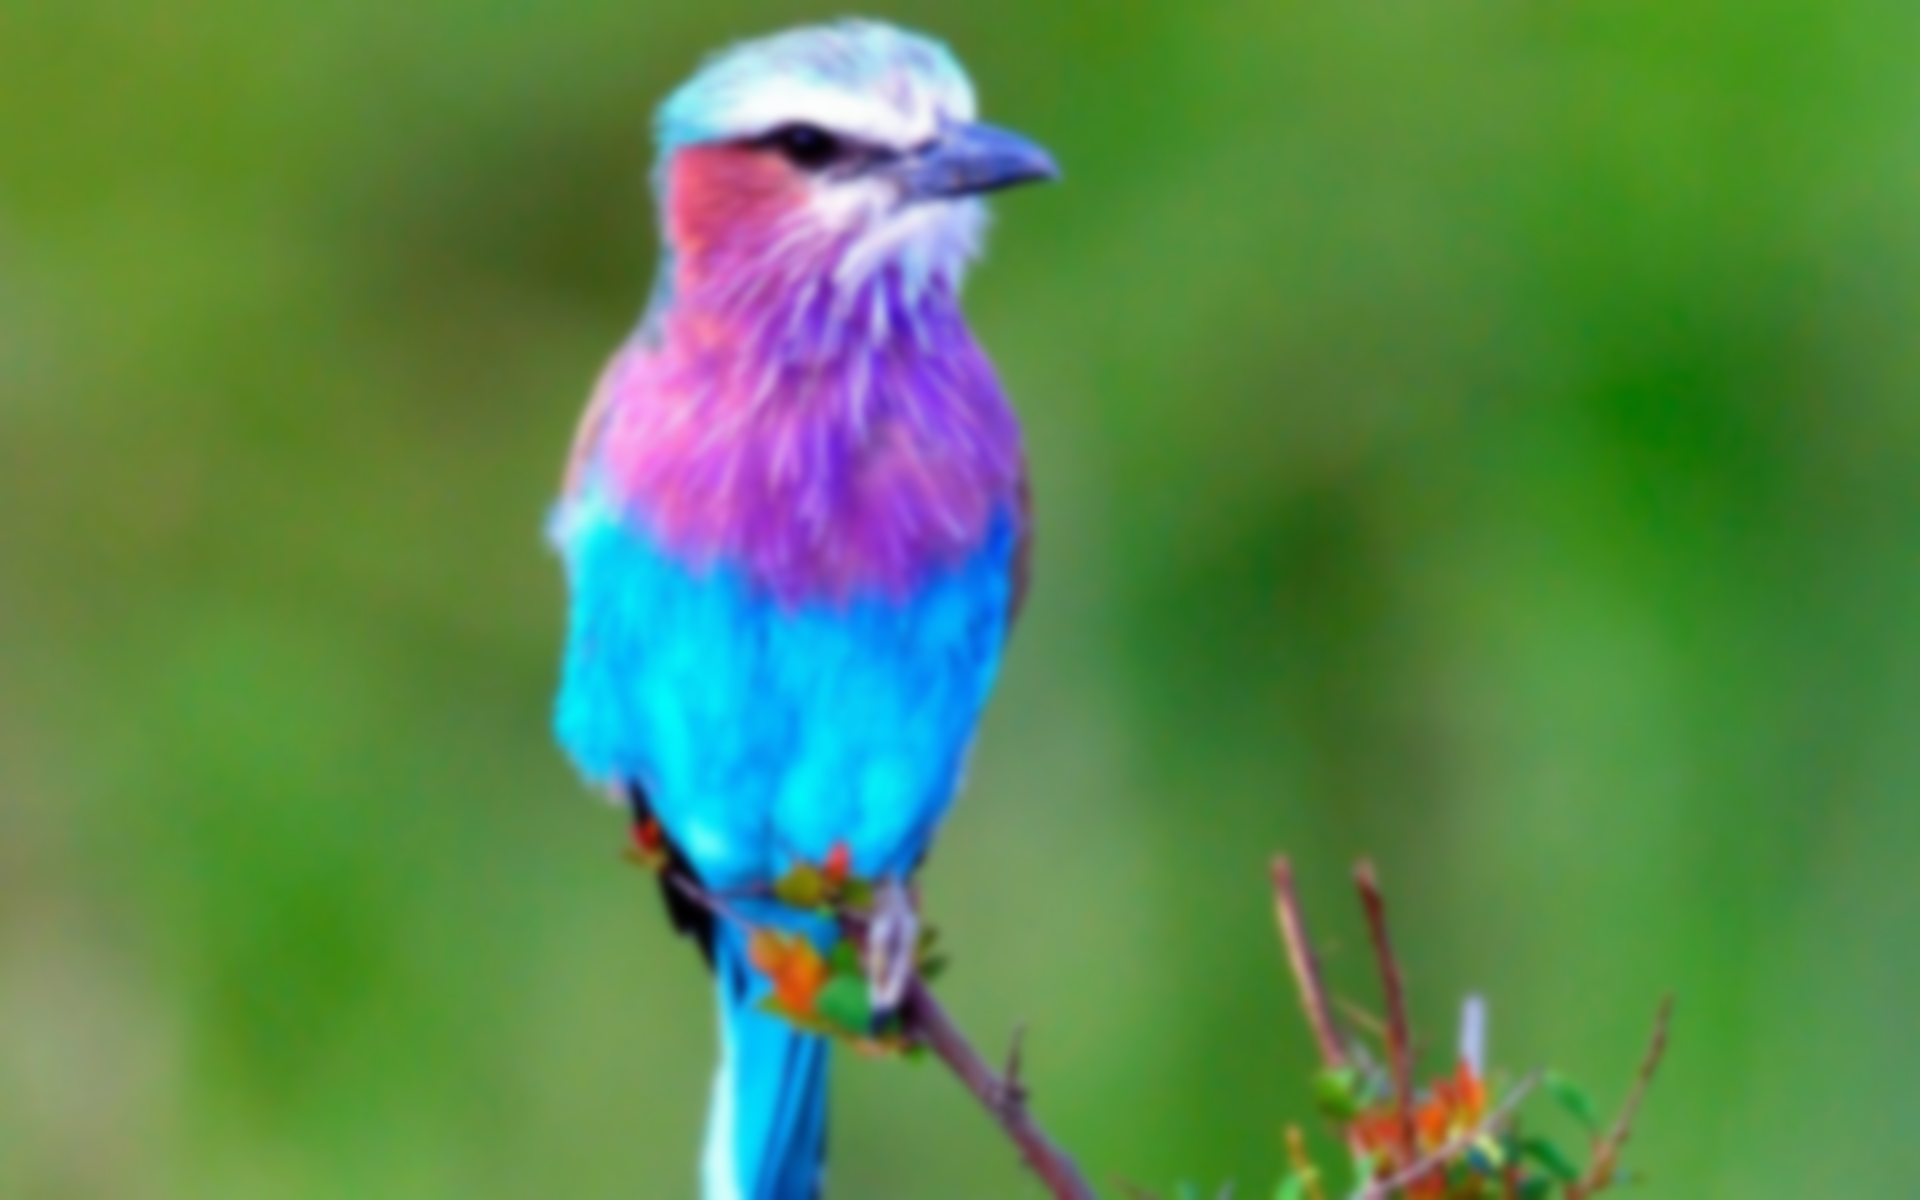

In [6]:
Image.fromarray(im2)

# Image derivatives

In [5]:
im = np.array(Image.open('Resources/bird.jpg').convert('L'))

# Sobel derivative filters
imx = np.zeros(im.shape)
sobel(im, 1, imx)

imy = np.zeros(im.shape)
sobel(im, 0, imy)

magnitude = np.sqrt(imx**2 + imy**2)

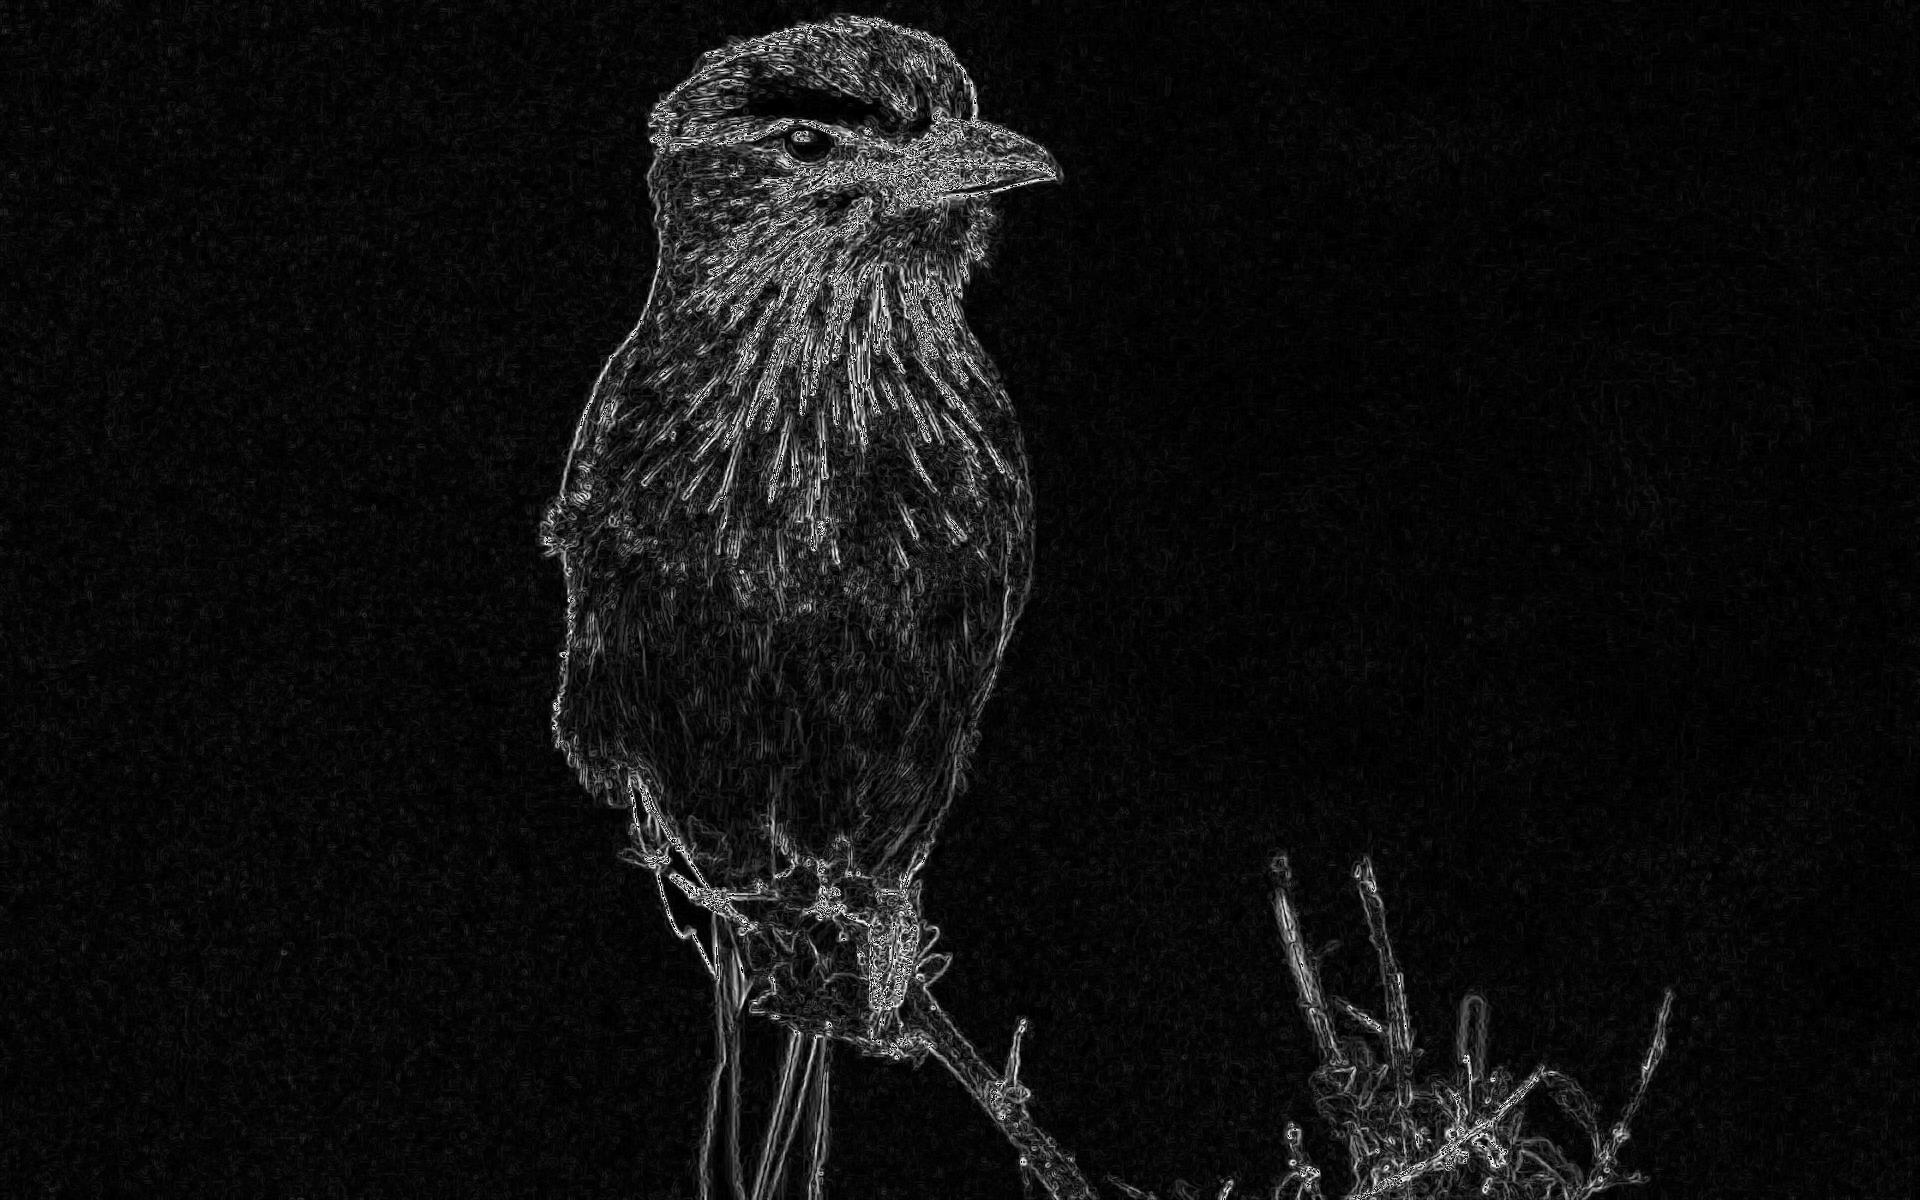

In [12]:
Image.fromarray(np.uint8(magnitude))

In [16]:
sigma = 5 # standard deviation

imx = np.zeros(im.shape)
gaussian_filter(im, (sigma, sigma), (0, 1), imx)

imy = np.zeros(im.shape)
gaussian_filter(im, (sigma, sigma), (1, 0), imy)

magnitude = np.sqrt(imx**2 + imy**2)

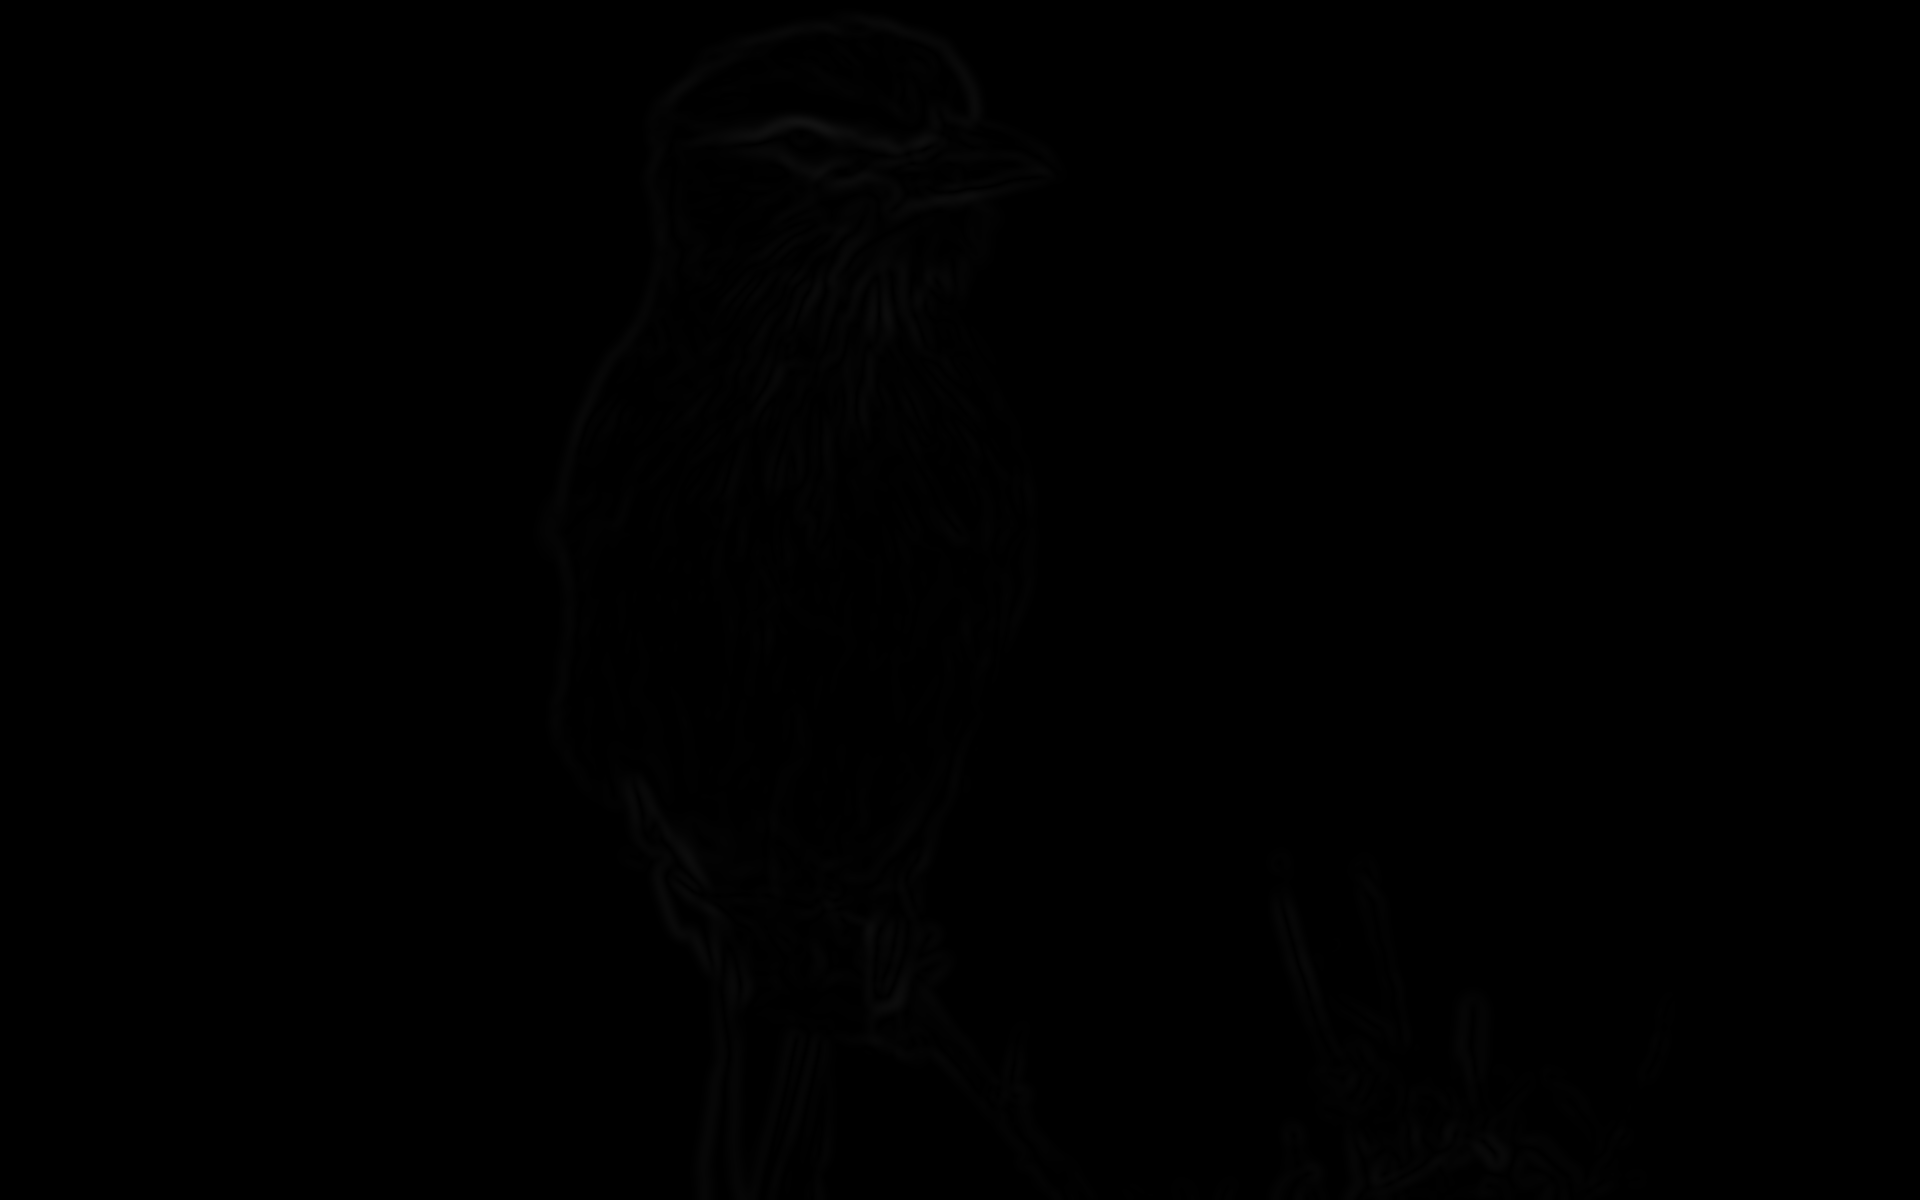

In [23]:
Image.fromarray(np.uint8(magnitude))

# Morphology - counting objects

In [13]:
# load image and threshold to make sure it is binary
im = np.array(Image.open('Resources/binary_images.jpg').convert('L'))
im = 1 * (im < 128)

labels, nbr_objects = label(im)
print(f'Number of objects: {nbr_objects}')

Number of objects: 12


In [14]:
# morphology - opening to separate objects better
im_open = binary_opening(im, np.ones((9, 5)), iterations=2)

labels_open, nbr_objects_open = label(im_open)
print(f'Number of objects: {nbr_objects_open}')

Number of objects: 9
